# PANdeMaiz — Seismic Dataset Builder v3

Genera el dataset de espectrogramas para entrenar la CNN de detección sísmica.

## Entradas

| Fuente | Formato | Clase asignada |
|--------|---------|----------------|
| `DatosObtenidos/PANAcelerografo/` | `.bin` ADXL345 (calle, parque, laboratorio) | **0 — Ruido ambiental** |
| `DatosObtenidos/Acelerografo_SGC/` | `.anc` SGC 2023–2026 | **0 y 1** (via STA/LTA automatico) |

## Salidas

- `Dataset/0_Ruido/*.npy` — espectrogramas de ruido ambiental
- `Dataset/1_Sismo/*.npy` — espectrogramas de eventos sismicos

## Shape de cada `.npy`

```
(65, 12, 3)  float32   <- para WIN_SECONDS = 4.0
  |    |   +- canales: EW, VER, NS
  |    +----- bins de tiempo (~0.33 s por bin)
  +---------- bins de frecuencia (0-100 Hz, Delta_f aprox 1.56 Hz)
Escala: log10(PSD + 1e-12)  [g^2/Hz]
```

> Cambiar solo `WIN_SECONDS` en la celda de constantes. `WIN_SAMPLES`, `STRIDE_SAMPLES` y `T_BINS` se recalculan solos.

## Meta de balance

| Clase | Target |
|-------|--------|
| 1_Sismo | 2 000 muestras |
| 0_Ruido | 3 000 muestras |

## Mejoras sobre v2

- Ventana de tiempo configurable (`WIN_SECONDS`)
- Ruido ambiental desde `.bin` ADXL345 en entornos reales (calle, parque, laboratorio)
- Ruido de fondo sismico desde periodos silenciosos de `.anc` SGC (limitado a `MAX_RUIDO_WINDOWS` para no inundar la clase)
- Augmentacion ampliada: ruido gaussiano + desplazamiento temporal + escalado de amplitud — 4 veces mas muestras por archivo fuente
- Procesamiento en batch: detecta automaticamente archivos ya procesados, seguro de relanzar sin duplicados
- Balance controlado por targets configurables (`TARGET_SISMO`, `TARGET_RUIDO`)

In [1]:
import math
import re
import struct
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import spectrogram

try:
    from obspy.signal.trigger import classic_sta_lta, trigger_onset
    OBSPY_AVAILABLE = True
except ImportError:
    OBSPY_AVAILABLE = False
    warnings.warn('ObsPy no disponible — usando implementacion NumPy para STA/LTA')

# ── Rutas ─────────────────────────────────────────────────────
BASE_DIR  = Path('.')
ANC_ROOT  = BASE_DIR / 'DatosObtenidos' / 'Acelerografo_SGC'
BIN_ROOT  = BASE_DIR / 'DatosObtenidos' / 'PANAcelerografo'
DIR_RUIDO = BASE_DIR / 'Dataset' / '0_Ruido'
DIR_SISMO = BASE_DIR / 'Dataset' / '1_Sismo'
DIR_RUIDO.mkdir(parents=True, exist_ok=True)
DIR_SISMO.mkdir(parents=True, exist_ok=True)

# ── Senal ─────────────────────────────────────────────────────
FS             = 200

WIN_SECONDS    = 4.0        # <- AJUSTABLE: duracion de ventana en segundos
STRIDE_SECONDS = 1.0        # <- AJUSTABLE: paso entre ventanas en segundos
WIN_SAMPLES    = int(WIN_SECONDS    * FS)
STRIDE_SAMPLES = int(STRIDE_SECONDS * FS)

# ── Espectrograma ─────────────────────────────────────────────
NPERSEG   = 128
NOVERLAP  = 64
T_BINS    = math.ceil((WIN_SAMPLES - NOVERLAP) / (NPERSEG - NOVERLAP))
FREQ_BINS = NPERSEG // 2 + 1   # 65 para NPERSEG=128
print(f'WIN={WIN_SECONDS}s  shape espectrograma: ({FREQ_BINS}, {T_BINS}, 3)')

# ── Formato binario ESP32/ADXL345 ─────────────────────────────
MAGIC       = 0xDA7A1345
HEADER_FMT  = '<IHH'
HEADER_SIZE = struct.calcsize(HEADER_FMT)   # 8 bytes
SAMPLE_FMT  = '<Ihhh'
SAMPLE_SIZE = struct.calcsize(SAMPLE_FMT)   # 10 bytes
SCALE_G     = 0.0039   # g/LSB (ADXL345 full-res +-2g)

# ── Formato SGC (.anc) ────────────────────────────────────────
SGC_HEADER_ROWS = 20
G_TO_CMS2       = 980.665

# ── STA/LTA ───────────────────────────────────────────────────
STA_SAMPLES     = int(0.5  * FS)
LTA_SAMPLES     = int(10.0 * FS)
TRIGGER_ON      = 2.5
TRIGGER_OFF     = 1.5
TRIGGER_OVERLAP = 0.30

# ── Targets de balance ────────────────────────────────────────
TARGET_SISMO      = 2000   # parar cuando 1_Sismo alcance este numero
TARGET_RUIDO      = 3000   # parar cuando 0_Ruido alcance este numero
MAX_PER_EVENT     = 10     # archivos .anc por subcarpeta de evento
MAX_BIN_PER_LOC   = 5      # archivos .bin por subcarpeta de entorno
MAX_RUIDO_WINDOWS = 10     # ventanas de ruido max. por senal de .anc

# ── Augmentacion ─────────────────────────────────────────────
SIGMA_DICT = {'x': 0.000496, 'y': 0.000683, 'z': 0.001320}  # g/LSB sensor

WIN=4.0s  shape espectrograma: (65, 12, 3)


## Celda 2 — Funciones base (compatibles con v2)

Estas funciones forman el pipeline de procesamiento de señal. Son identicas a v2 para garantizar compatibilidad con los `.npy` ya generados.

### `parse_bin(path)`
Lee el formato binario propietario del DataLogger ESP32/ADXL345:
- **Cabecera (8 bytes):** `MAGIC = 0xDA7A1345`, version (uint16), sample rate (uint16)
- **Muestras (10 bytes c/u):** timestamp ms (uint32) + ax/ay/az (int16 cada uno)
- **Conversion:** x 0.0039 g/LSB — escala del ADXL345 en modo +/-2 g full-resolution
- **Retorna:** `header (dict)`, `data (N, 4) float32` — columnas `[t_s, ax_g, ay_g, az_g]`

### `parse_anc(path)`
Lee el formato `.anc` del Servicio Geologico Colombiano (SGC):
- Cabecera de 20 lineas con metadatos: magnitud, estacion, distancia epicentral, intervalo de muestreo, profundidad, latitud/longitud del evento
- Datos: 3 columnas en cm/s^2 (EW, VER, NS), divididas por 980.665 para convertir a g
- **Retorna:** `meta (dict)`, `data (N, 3) float32` en g

### `aplicar_sta_lta(data_g)`
Deteccion automatica de eventos sismicos usando el algoritmo **STA/LTA** (Short-Term Average / Long-Term Average):
1. Calcula la norma vectorial `sqrt(ax^2 + ay^2 + az^2)` para usar los 3 canales combinados
2. STA: promedio de energia en ventana corta de **100 muestras (0.5 s)**
3. LTA: promedio de energia en ventana larga de **2 000 muestras (10 s)**
4. CFT (Characteristic Function) = STA / LTA
5. Trigger ON >= 2.5 — inicio del evento; Trigger OFF <= 1.5 — fin del evento
- **Retorna:** `cft (N,) float32`, `is_sismo (N,) bool`, `events [[i_on, i_off], ...]`

### `sliding_windows(data)`
Divide la señal en ventanas deslizantes de `WIN_SAMPLES` muestras con paso `STRIDE_SAMPLES`.
Con los valores por defecto: ventanas de **800 muestras (4 s)**, paso de **200 muestras (1 s)**.
Hay solapamiento del 75% entre ventanas consecutivas.

### `compute_spectrogram(window)`
Convierte una ventana temporal en el **tensor de caracteristicas** que usara la CNN:
1. Para cada canal (EW, VER, NS): espectrograma de Welch (ventana Hann, `nperseg=128`, `noverlap=64`)
2. Escala: `log10(PSD + 1e-12)` — comprime el rango dinamico sismico (varios ordenes de magnitud)
3. Apila los 3 canales en el eje -1
- **Retorna:** `(65, T_BINS, 3) float32`

### `classify_window(start_idx, is_sismo_mask)`
Etiqueta una ventana segun su contenido sismico:
- **1 (sismo):** >= 30% de las muestras de la ventana estan dentro de un evento STA/LTA
- **0 (ruido):** menos del 30% de las muestras son sismicas

In [2]:
def parse_bin(path):
    """Lee .bin del DataLogger ESP32/ADXL345.
    Retorna: header (dict), data (N,4) float32 [t_s, ax_g, ay_g, az_g]"""
    path = Path(path)
    rows = []
    with open(path, 'rb') as f:
        raw_hdr = f.read(HEADER_SIZE)
        magic, version, sample_rate = struct.unpack(HEADER_FMT, raw_hdr)
        if magic != MAGIC:
            raise ValueError(f'Magic invalido: 0x{magic:08X} en {path.name}')
        header = {'magic': magic, 'version': version, 'sample_rate': sample_rate}
        while True:
            raw = f.read(SAMPLE_SIZE)
            if len(raw) < SAMPLE_SIZE:
                break
            ts_ms, ax, ay, az = struct.unpack(SAMPLE_FMT, raw)
            rows.append([ts_ms / 1000.0, ax * SCALE_G, ay * SCALE_G, az * SCALE_G])
    return header, np.array(rows, dtype=np.float32)


def parse_anc(path):
    """Lee .anc del SGC.
    Retorna: meta (dict), data (N,3) float32 en g [EW, VER, NS]"""
    path = Path(path)
    meta = {}
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        lines = f.readlines()
    header_text = ''.join(lines[:SGC_HEADER_ROWS])
    for key, pattern in [
        ('magnitud',        r'M=([\d.]+)'),
        ('codigo_estacion', r'CODIGO DE LA ESTACION:\s*(\S+)'),
        ('estacion',        r'^ESTACION:\s*(.+)'),
        ('dist_epicentral', r'DISTANCIA EPICENTRAL:\s*([\d.]+)'),
        ('intervalo_s',     r'INTERVALO DE MUESTREO.*?:\s*([\d.]+)'),
        ('n_datos',         r'NUMERO DE DATOS:\s*(\d+)'),
        ('profundidad_km',  r'PROFUNDIDAD.*?:\s*([\d.]+)'),
        ('lat_evento',      r'LATITUD DEL EVENTO.*?:\s*([\d.-]+)'),
        ('lon_evento',      r'LONGITUD DEL EVENTO.*?:\s*([\d.-]+)'),
    ]:
        m = re.search(pattern, header_text, re.MULTILINE | re.IGNORECASE)
        if m:
            meta[key] = m.group(1).strip()
    rows = []
    for line in lines[SGC_HEADER_ROWS:]:
        line = line.strip()
        if not line:
            continue
        try:
            vals = [float(v) for v in line.split()]
            if len(vals) == 3:
                rows.append(vals)
        except ValueError:
            continue
    data_g = np.array(rows, dtype=np.float32) / G_TO_CMS2
    return meta, data_g


def _sta_lta_numpy(data, nsta, nlta):
    """Fallback NumPy de classic STA/LTA (sin ObsPy)."""
    n    = len(data)
    data = data.astype(np.float64) ** 2
    cft  = np.zeros(n)
    for i in range(nlta, n):
        sta = data[i - nsta:i].mean()
        lta = data[i - nlta:i].mean()
        cft[i] = sta / (lta + 1e-12)
    return cft


def aplicar_sta_lta(data_g,
                    nsta=STA_SAMPLES, nlta=LTA_SAMPLES,
                    trigger_on=TRIGGER_ON, trigger_off=TRIGGER_OFF):
    """STA/LTA sobre senal multicanal (norma vectorial).
    Retorna: cft (N,), is_sismo (N,) bool, events list[[i_on,i_off]]"""
    composite = np.sqrt(np.sum(data_g.astype(np.float64) ** 2, axis=1))
    if OBSPY_AVAILABLE:
        cft    = classic_sta_lta(composite, nsta, nlta)
        events = trigger_onset(cft, trigger_on, trigger_off).tolist()
    else:
        cft    = _sta_lta_numpy(composite, nsta, nlta)
        events = []
        on = False
        i_on = 0
        for i, v in enumerate(cft):
            if not on and v >= trigger_on:
                on   = True
                i_on = i
            elif on and v <= trigger_off:
                events.append([i_on, i])
                on = False
        if on:
            events.append([i_on, len(cft) - 1])
    is_sismo = np.zeros(len(data_g), dtype=bool)
    for i_on, i_off in events:
        is_sismo[i_on:i_off + 1] = True
    return cft.astype(np.float32), is_sismo, events


def sliding_windows(data, win_samples=WIN_SAMPLES, stride=STRIDE_SAMPLES):
    """Segmenta data (N,C) en ventanas deslizantes.
    Retorna lista de (ventana_2D, indice_inicio)."""
    result = []
    n      = len(data)
    start  = 0
    while start + win_samples <= n:
        result.append((data[start:start + win_samples], start))
        start += stride
    return result


def compute_spectrogram(window, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP):
    """Espectrograma 3-canal en escala log10.
    Retorna: (freq_bins, time_bins, 3) float32"""
    specs = []
    for ch in range(window.shape[1]):
        _, _, Sxx = spectrogram(
            window[:, ch].astype(np.float64),
            fs=fs, nperseg=nperseg, noverlap=noverlap,
            scaling='density', window='hann'
        )
        specs.append(np.log10(Sxx + 1e-12).astype(np.float32))
    return np.stack(specs, axis=-1)


def classify_window(start_idx, is_sismo_mask,
                    win_samples=WIN_SAMPLES, overlap_thr=TRIGGER_OVERLAP):
    """1 si >=overlap_thr de muestras en la ventana son sismicas, 0 si no."""
    segment = is_sismo_mask[start_idx:start_idx + win_samples]
    return 1 if segment.mean() >= overlap_thr else 0

## Celda 3 — Augmentacion de datos (nuevas en v3)

La augmentacion es clave para alcanzar `TARGET_SISMO = 2000` procesando pocos archivos `.anc` reales.
Cada señal genera **4 versiones**, multiplicando el dataset sin introducir sesgo:

| Tag | Tecnica | Que simula |
|-----|---------|-----------|
| `orig` | Señal original sin modificar | — |
| `gauss` | Ruido gaussiano con sigma medido del sensor real | Variabilidad de la electronica del ADXL345 |
| `shift` | Desplazamiento circular +/-0.2 s (`np.roll`) | Distinta posicion del onset del evento en la ventana |
| `scale` | Escalado de amplitud x0.7-1.3 | Diferente distancia epicentral o magnitud |

Los sigma del ruido gaussiano estan en `SIGMA_DICT` y fueron medidos empiricamente sobre capturas del ADXL345 en reposo.
El generador aleatorio usa `hash(stem)` como semilla — resultados **reproducibles** por archivo.

`build_augmented_signals(data_g, sigma_dict, seed)` agrupa las 4 versiones en una lista `[(tag, señal), ...]`
que luego itera `process_anc_file_v3`.

In [3]:
def add_gaussian_noise(data_g, sigma_dict, rng):
    """Ruido gaussiano independiente por eje (sigma del sensor real)."""
    sigmas = np.array([sigma_dict['x'], sigma_dict['y'], sigma_dict['z']], dtype=np.float32)
    return (data_g + rng.standard_normal(data_g.shape).astype(np.float32) * sigmas)


def add_time_shift(data_g, rng, max_shift_s=0.2, fs=FS):
    """Desplazamiento circular +-max_shift_s segundos."""
    max_shift = int(max_shift_s * fs)
    shift     = int(rng.integers(-max_shift, max_shift + 1))
    return np.roll(data_g, shift, axis=0)


def add_amplitude_scale(data_g, rng, scale_range=(0.7, 1.3)):
    """Escala de amplitud aleatoria uniforme."""
    return (data_g * np.float32(rng.uniform(*scale_range)))


def build_augmented_signals(data_g, sigma_dict, seed):
    """4 versiones de la senal: orig + gauss + shift + scale.
    Retorna lista de (tag, senal)."""
    rng = np.random.default_rng(seed)
    return [
        ('orig',  data_g),
        ('gauss', add_gaussian_noise(data_g, sigma_dict, rng)),
        ('shift', add_time_shift(data_g, rng)),
        ('scale', add_amplitude_scale(data_g, rng)),
    ]

## Celda 4 — Utilidades de control de progreso

Estas funciones permiten **relanzar el notebook sin generar duplicados**, incluso si una sesion anterior se interrumpio a mitad.

- **`count_class(cls_dir)`** — cuenta `.npy` existentes en una carpeta de clase
- **`get_processed_stems_anc()`** — lee los nombres `sgc_*.npy` existentes en ambas clases y extrae los stems de `.anc` ya procesados
- **`get_processed_stems_bin()`** — lee los nombres `noise_*.npy` en `0_Ruido` y extrae los stems de `.bin` ya procesados

### Convencion de nombres de salida

Los nombres de archivo incluyen toda la informacion de trazabilidad:

```
sgc_{stem}_{tag}_{clase}_w{idx:04d}.npy
|    |       |     |         +-- indice de ventana dentro del archivo
|    |       |     +----------- 1S (sismo) o 0R (ruido)
|    |       +----------------- orig / gauss / shift / scale
|    +------------------------- nombre del .anc sin extension
+------------------------------ prefijo de fuente SGC

Ejemplo: sgc_SGC2023keosra_ARGC_10_gauss_1S_w0042.npy

noise_{entorno}_{stem}_w{idx:04d}.npy
|      |          |        +-- indice de ventana
|      |          +----------- nombre del .bin sin extension
|      +---------------------- nombre de la subcarpeta de entorno
+------------------------------ prefijo de fuente sensor

Ejemplo: noise_calle_barranquilla_accel_20260504_161511_w0012.npy
```

In [4]:
def count_class(cls_dir):
    return len(list(Path(cls_dir).glob('*.npy')))


def get_processed_stems_anc():
    """Stems de .anc ya procesados (lee ambas carpetas de clase)."""
    processed = set()
    for cls_dir in (DIR_RUIDO, DIR_SISMO):
        for npy in cls_dir.glob('sgc_*.npy'):
            # patron: sgc_{stem}_{tag}_{cls}_w{idx}.npy
            parts = npy.stem.split('_')
            processed.add('_'.join(parts[1:-3]))   # quita 'sgc' y tag/cls/widx
    return processed


def get_processed_stems_bin():
    """Stems de .bin ya procesados (lee prefijo 'noise_' en 0_Ruido)."""
    processed = set()
    for npy in DIR_RUIDO.glob('noise_*.npy'):
        parts = npy.stem.split('_')
        try:
            accel_idx = next(i for i, p in enumerate(parts) if p == 'accel')
            processed.add('_'.join(parts[accel_idx:-1]))   # accel_YYYYMMDD_HHMMSS
        except StopIteration:
            pass
    return processed

## Celda 5 — Procesadores de archivo individuales

### `process_anc_file_v3(anc_path)`
Pipeline completo para **un archivo `.anc`** del SGC. Pasos internos:

1. **Validacion de sample rate:** lee `meta['intervalo_s']` — si `FS_anc != 200 Hz`, emite warning y omite el archivo
2. **Deteccion de eventos:** STA/LTA sobre la norma vectorial `sqrt(ax^2+ay^2+az^2)`
3. **Augmentacion:** genera 4 versiones de toda la señal (orig, gauss, shift, scale)
4. **Ventanas deslizantes:** para cada version extrae ventanas de `WIN_SAMPLES` muestras
5. **Clasificacion y guardado:**
   - `label == 1` (sismo) — guarda en `1_Sismo/`, **sin limite** (son las muestras valiosas)
   - `label == 0` (ruido) — guarda en `0_Ruido/`, **maximo `MAX_RUIDO_WINDOWS = 10` por version** de señal

El cap de ruido evita que los periodos silenciosos pre/post evento de un `.anc` dominen la clase 0.
Con 4 versiones x 10 ventanas = maximo **40 muestras de ruido por archivo `.anc`**.

### `process_bin_file(bin_path, prefix)`
Pipeline para **un archivo `.bin`** del ADXL345:

1. Parsea el formato binario ESP32 (MAGIC + muestras de 10 bytes)
2. Extrae los canales ax, ay, az (descarta la columna de tiempo)
3. Aplica ventanas deslizantes
4. Clasifica **todas** las ventanas como Clase 0 — no se aplica STA/LTA porque las grabaciones de campo no contienen sismos
5. Calcula el espectrograma y guarda cada ventana como `.npy`

Retorna la cantidad de espectrogramas guardados.

In [5]:
def process_anc_file_v3(anc_path, sigma_dict=SIGMA_DICT,
                         save_ruido=True, max_ruido_windows=MAX_RUIDO_WINDOWS):
    """
    Pipeline .anc -> espectrogramas con etiquetado STA/LTA.

    Genera 4 versiones (orig, gauss, shift, scale).
    Para clase 0 guarda maximo max_ruido_windows ventanas por version.
    Retorna: {'1_Sismo': n, '0_Ruido': n, 'eventos': n}
    """
    anc_path = Path(anc_path)
    stem     = anc_path.stem

    meta, data_g = parse_anc(anc_path)

    if 'intervalo_s' in meta:
        fs_anc = round(1.0 / float(meta['intervalo_s']))
        if fs_anc != FS:
            print(f'  [SKIP] {stem}: FS_anc={fs_anc} Hz != {FS} Hz')
            return {'1_Sismo': 0, '0_Ruido': 0, 'eventos': 0}

    if len(data_g) < WIN_SAMPLES:
        print(f'  [SKIP] {stem}: senal corta ({len(data_g)} muestras)')
        return {'1_Sismo': 0, '0_Ruido': 0, 'eventos': 0}

    _, is_sismo, events = aplicar_sta_lta(data_g)

    seed    = hash(stem) % (2 ** 31)
    signals = build_augmented_signals(data_g, sigma_dict, seed)
    stats   = {'1_Sismo': 0, '0_Ruido': 0, 'eventos': len(events)}

    for tag, signal in signals:
        wins                 = sliding_windows(signal)
        ruido_en_esta_senal  = 0
        for win_idx, (win, start_idx) in enumerate(wins):
            label = classify_window(start_idx, is_sismo)
            if label == 0:
                if not save_ruido or ruido_en_esta_senal >= max_ruido_windows:
                    continue
                ruido_en_esta_senal += 1
                out_dir  = DIR_RUIDO
                cls_tag  = '0R'
                stat_key = '0_Ruido'
            else:
                out_dir  = DIR_SISMO
                cls_tag  = '1S'
                stat_key = '1_Sismo'

            fname = out_dir / f'sgc_{stem}_{tag}_{cls_tag}_w{win_idx:04d}.npy'
            np.save(str(fname), compute_spectrogram(win))
            stats[stat_key] += 1

    mag  = meta.get('magnitud', '?')
    dist = meta.get('dist_epicentral', '?')
    print(f'  [ANC] {stem[:48]:<48}  M={mag} d={dist}km '
          f'-> {stats["1_Sismo"]:4d} sismo | {stats["0_Ruido"]:3d} ruido')
    return stats


def process_bin_file(bin_path, prefix='noise'):
    """
    Pipeline .bin -> espectrogramas de Clase 0 (ruido ambiental).
    Retorna numero de muestras guardadas.
    """
    bin_path = Path(bin_path)
    stem     = bin_path.stem
    try:
        _, data = parse_bin(bin_path)
    except (ValueError, struct.error) as e:
        print(f'  [SKIP] {stem}: {e}')
        return 0

    wins  = sliding_windows(data[:, 1:])   # excluye columna de tiempo
    saved = 0
    for idx, (win, _) in enumerate(wins):
        fname = DIR_RUIDO / f'{prefix}_{stem}_w{idx:04d}.npy'
        np.save(str(fname), compute_spectrogram(win))
        saved += 1
    print(f'  [BIN] {stem:<50}  -> {saved:4d} espectrogramas ruido')
    return saved

## Celda 6 — Procesamiento en batch

Las funciones de batch orquestan el procesamiento de multiples archivos con **control de balance automatico**.

### `batch_process_bin(bin_root)`
Itera sobre las subcarpetas de entorno en `PANAcelerografo/` para capturar **diversidad de ruido ambiental**:

```
PANAcelerografo/
+-- Datos_barrientos/     -> hasta MAX_BIN_PER_LOC = 5 archivos
+-- Onda_Seno/            -> hasta MAX_BIN_PER_LOC = 5 archivos
+-- calle_barranquilla/   -> hasta MAX_BIN_PER_LOC = 5 archivos
+-- doradal/              -> hasta MAX_BIN_PER_LOC = 5 archivos
```

Se detiene automaticamente cuando `0_Ruido >= TARGET_RUIDO = 3 000`.

### `batch_process_anc(anc_root)`
Itera sobre las subcarpetas de evento en `Acelerografo_SGC/` para capturar **diversidad temporal
y geografica** de sismos (2023-2026):

```
Acelerografo_SGC/
+-- 2023_keosra/          -> hasta MAX_PER_EVENT = 10 archivos .anc
+-- 2023_qdvyoj/          -> hasta MAX_PER_EVENT = 10 archivos .anc
+-- ...                   -> hasta MAX_PER_EVENT = 10 archivos .anc
```

Se detiene automaticamente cuando `1_Sismo >= TARGET_SISMO = 2 000`.
Omite archivos ya procesados en sesiones anteriores (deteccion por nombre de `.npy` existente).

In [6]:
def batch_process_bin(bin_root=BIN_ROOT,
                       max_per_location=MAX_BIN_PER_LOC,
                       target_ruido=TARGET_RUIDO):
    """
    Procesa .bin del ADXL345 como Clase 0 (ruido ambiental diverso).
    Hasta max_per_location archivos por subcarpeta de entorno.
    Para cuando 0_Ruido alcanza target_ruido.
    """
    already_done = get_processed_stems_bin()
    total_saved  = 0
    for loc_dir in sorted(Path(bin_root).iterdir()):
        if not loc_dir.is_dir():
            continue
        bin_files = sorted(loc_dir.rglob('*.bin'))[:max_per_location]
        print(f'\n[ENTORNO] {loc_dir.name}  ({len(bin_files)} archivos)')
        for bin_path in bin_files:
            if count_class(DIR_RUIDO) >= target_ruido:
                print(f'[OK] Target ruido alcanzado: {count_class(DIR_RUIDO)}')
                return total_saved
            if bin_path.stem in already_done:
                print(f'  [SKIP] {bin_path.stem} (ya procesado)')
                continue
            prefix       = f'noise_{loc_dir.name}'
            total_saved += process_bin_file(bin_path, prefix=prefix)
    print(f'\nTotal muestras ruido anadidas (.bin): {total_saved}')
    return total_saved


def batch_process_anc(anc_root=ANC_ROOT,
                       max_per_event=MAX_PER_EVENT,
                       target_sismo=TARGET_SISMO,
                       sigma_dict=SIGMA_DICT):
    """
    Procesa .anc del SGC con STA/LTA y augmentacion.
    Hasta max_per_event archivos por subcarpeta de evento.
    Para cuando 1_Sismo alcanza target_sismo.
    """
    already_done = get_processed_stems_anc()
    anc_files    = []
    for event_dir in sorted(Path(anc_root).iterdir()):
        if event_dir.is_dir():
            anc_files.extend(sorted(event_dir.glob('*.anc'))[:max_per_event])

    print(f'Archivos .anc disponibles: {len(anc_files)} '
          f'({len(already_done)} ya procesados previamente)')
    processed = 0
    for anc_path in anc_files:
        if count_class(DIR_SISMO) >= target_sismo:
            print(f'[OK] Target sismo alcanzado: {count_class(DIR_SISMO)}')
            break
        if anc_path.stem in already_done:
            continue
        process_anc_file_v3(anc_path, sigma_dict,
                              save_ruido=True,
                              max_ruido_windows=MAX_RUIDO_WINDOWS)
        processed += 1
    print(f'\nArchivos .anc procesados esta sesion: {processed}')

## Celda 7 — Reporte de balance del dataset

`compute_dataset_stats(show_samples=True)` muestra el estado del dataset en cualquier momento:

- Conteo de `.npy` en cada clase
- **Ratio ruido:sismo** — objetivo <= 1.5:1
- Shape y dtype de una muestra aleatoria (verificacion de formato)
- Grafica de barras horizontal para visualizar el balance

### Interpretacion del ratio

| Ratio | Interpretacion |
|-------|---------------|
| <= 1.5:1 | Balanceado — apto para entrenamiento |
| 1.5-3:1 | Leve desbalance — usar `class_weight` en Keras |
| > 3:1 | Desbalance severo — el modelo aprendera a predecir siempre "ruido" |

Si el ratio final supera 1.5:1, ajustar `TARGET_SISMO` hacia arriba o `MAX_RUIDO_WINDOWS`
hacia abajo y relanzar el Paso 3.

In [7]:
def compute_dataset_stats(show_samples=True):
    """Imprime y grafica el balance actual del dataset."""
    n_ruido = count_class(DIR_RUIDO)
    n_sismo = count_class(DIR_SISMO)
    ratio   = n_ruido / max(n_sismo, 1)

    print('=' * 52)
    print(f'  0_Ruido : {n_ruido:6d} muestras')
    print(f'  1_Sismo : {n_sismo:6d} muestras')
    print(f'  Ratio   : {ratio:.2f}:1  (ruido:sismo)')
    print('=' * 52)

    if show_samples:
        for cls_name, cls_dir in [('0_Ruido', DIR_RUIDO), ('1_Sismo', DIR_SISMO)]:
            npys = list(cls_dir.glob('*.npy'))
            if npys:
                sample = np.load(npys[0])
                print(f'  [{cls_name}] shape={sample.shape} dtype={sample.dtype}')

    fig, ax = plt.subplots(figsize=(6, 3))
    bars = ax.barh(['0_Ruido', '1_Sismo'], [n_ruido, n_sismo],
                   color=['#4472C4', '#ED7D31'])
    ax.bar_label(bars, padding=4, fmt='%d')
    ax.set_xlabel('Numero de muestras')
    ax.set_title(f'Balance del dataset   ratio {ratio:.2f}:1')
    ax.set_xlim(0, max(n_ruido, n_sismo) * 1.15)
    plt.tight_layout()
    plt.show()

## Celda 8 — Diagnostico STA/LTA (opcional)

`plot_sta_lta_diagnostic(anc_path, channel=1)` genera una figura de **3 paneles** para verificar
que el STA/LTA esta detectando correctamente los eventos antes de procesar el batch completo:

1. **Panel superior:** señal de aceleracion del canal indicado (`channel=1` = VER por defecto)
2. **Panel central:** funcion de caracteristica CFT con lineas de umbral ON (rojo) y OFF (verde)
3. **Panel inferior:** mascara booleana de regiones marcadas como sismicas

### Cuando usarlo

- Al agregar archivos `.anc` de una nueva carpeta de eventos (verificar que STA/LTA los detecta)
- Si un archivo `.anc` genera 0 muestras de sismo (el threshold puede ser demasiado alto)
- Si genera demasiadas muestras en señales de ruido (threshold demasiado bajo)

Descomentar la ultima linea de esta celda para probarlo con el primer `.anc` disponible en el disco.

In [8]:
def plot_sta_lta_diagnostic(anc_path, channel=1):
    """Grafica senal + CFT STA/LTA + mascara de eventos para un .anc."""
    meta, data_g = parse_anc(anc_path)
    cft, is_sismo, events = aplicar_sta_lta(data_g)

    t   = np.arange(len(data_g)) / FS
    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

    axes[0].plot(t, data_g[:, channel], lw=0.5)
    axes[0].set_ylabel('Aceleracion [g]')
    axes[0].set_title(f'{Path(anc_path).stem}   M={meta.get("magnitud", "?")}')

    axes[1].plot(t, cft, lw=0.5, color='darkorange')
    axes[1].axhline(TRIGGER_ON,  color='red',   ls='--', label=f'ON={TRIGGER_ON}')
    axes[1].axhline(TRIGGER_OFF, color='green', ls='--', label=f'OFF={TRIGGER_OFF}')
    axes[1].set_ylabel('CFT STA/LTA')
    axes[1].legend(loc='upper right', fontsize=8)

    axes[2].fill_between(t, is_sismo.astype(int), alpha=0.6, color='red')
    axes[2].set_ylabel('Sismo detectado')
    axes[2].set_xlabel('Tiempo [s]')
    axes[2].set_ylim(-0.1, 1.3)

    print(f'Eventos detectados: {len(events)}')
    for i_on, i_off in events:
        print(f'  t={i_on/FS:.1f}s -> {i_off/FS:.1f}s  ({(i_off-i_on)/FS:.1f}s duracion)')
    plt.tight_layout()
    plt.show()

# Descomentar para probar con el primer .anc disponible:
# plot_sta_lta_diagnostic(next(ANC_ROOT.rglob('*.anc')))

## Ejecucion principal

El etiquetado se realiza en **4 pasos secuenciales**. El proceso es seguro de relanzar:
los archivos ya procesados se omiten automaticamente.

| Paso | Accion | Clase generada |
|------|--------|---------------|
| 1 | Estado inicial — cuantas muestras existen ya | — |
| 2 | Procesar `.bin` ADXL345 — ruido ambiental real | 0_Ruido |
| 3 | Procesar `.anc` SGC — eventos sismicos + ruido de fondo | 1_Sismo + 0_Ruido |
| 4 | Reporte final con grafica de balance | — |

### Paso 1 — Estado inicial

Cuenta los `.npy` que ya existen en `Dataset/0_Ruido/` y `Dataset/1_Sismo/` antes de procesar nada.
Si hay muestras de sesiones anteriores (v2 o ejecuciones parciales de v3), los pasos siguientes
las respetan y solo anaden las faltantes.

Estado inicial del dataset:
  0_Ruido :   4236 muestras
  1_Sismo :   2876 muestras
  Ratio   : 1.47:1  (ruido:sismo)


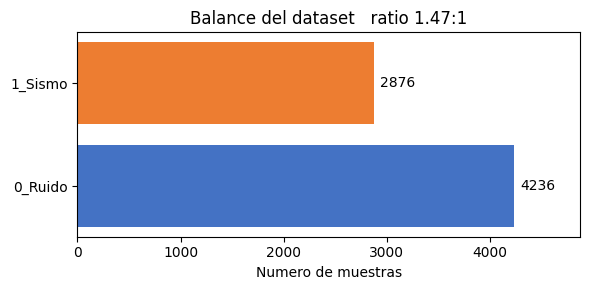

In [9]:
# Paso 1: Estado inicial
print('Estado inicial del dataset:')
compute_dataset_stats(show_samples=False)

### Paso 2 — Ruido ambiental desde ADXL345 (`.bin`)

Procesa archivos `.bin` capturados en entornos reales. Todas las ventanas se etiquetan como
**Clase 0 (ruido)** sin necesidad de STA/LTA — son grabaciones de campo sin sismos.

Configuracion activa: hasta `MAX_BIN_PER_LOC = 5` archivos por entorno,
para cuando `0_Ruido >= TARGET_RUIDO = 3 000`.

In [10]:
# Paso 2: Ruido ambiental desde .bin del ADXL345 (calle, parque, laboratorio)
print('Procesando archivos .bin (ruido ambiental)...')
batch_process_bin()

Procesando archivos .bin (ruido ambiental)...



[ENTORNO] Datos_barrientos  (5 archivos)
[OK] Target ruido alcanzado: 4236


0

### Paso 3 — Eventos sismicos desde SGC (`.anc`)

Procesa archivos `.anc` del SGC usando STA/LTA para detectar automaticamente los eventos.
Por cada archivo genera **4 versiones aumentadas** (orig + gauss + shift + scale):

- Ventanas sismicas (label=1) — `Dataset/1_Sismo/`
- Ventanas de silencio (label=0, max. 10 por version) — `Dataset/0_Ruido/`

Configuracion activa: hasta `MAX_PER_EVENT = 10` archivos por subcarpeta de evento,
para cuando `1_Sismo >= TARGET_SISMO = 2 000`.

In [11]:
# Paso 3: Sismo + ruido sismico desde .anc del SGC
print('Procesando archivos .anc (eventos SGC)...')
batch_process_anc()

Procesando archivos .anc (eventos SGC)...


Archivos .anc disponibles: 76 (43 ya procesados previamente)
[OK] Target sismo alcanzado: 2876

Archivos .anc procesados esta sesion: 0


### Paso 4 — Reporte final

Muestra el balance definitivo del dataset. Verificar que:
- `shape == (65, T_BINS, 3)` para ambas clases
- `ratio ruido:sismo <= 1.5:1`

Si el ratio es mayor, aumentar `TARGET_SISMO` o disminuir `MAX_RUIDO_WINDOWS` y relanzar el Paso 3.

Balance final del dataset:
  0_Ruido :   4236 muestras
  1_Sismo :   2876 muestras
  Ratio   : 1.47:1  (ruido:sismo)
  [0_Ruido] shape=(65, 11, 3) dtype=float32
  [1_Sismo] shape=(65, 11, 3) dtype=float32


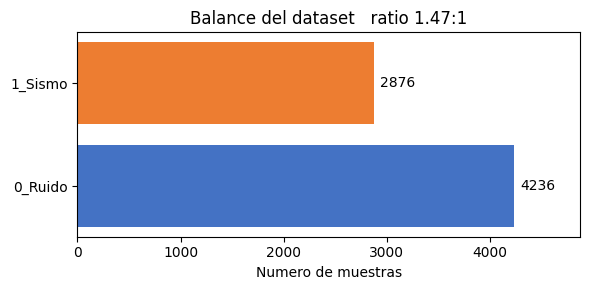

In [13]:
# Paso 4: Reporte final con grafico de balance
print('Balance final del dataset:')
compute_dataset_stats(show_samples=True)